# 실습 1. 로지스틱 회귀 이진분류 문제

## 데이터
- 파일 경로: `../data/fish.csv`
- 데이터 내용: 생선의 무게, 길이, 높이, 너비 등 수치 feature와 생선 종류
- 이번 실습 목표: `Bream`과 `Smelt` 두 종류를 로지스틱 회귀로 분류

## 사용할 컬럼

| 컬럼 | 의미 | 이번 실습 사용 |
|---|---|---|
| `Species` | 생선 종류 | target |
| `Weight` | 생선 무게 | feature |
| `Length` | 생선 길이 | feature |
| `Diagonal` | 대각선 길이 |  |
| `Height` | 높이 |  |
| `Width` | 너비 |  |

## 실습 목표
- 로지스틱 회귀가 분류 모델로 사용되는 흐름 확인
- `predict()`와 `predict_proba()` 결과 비교
- `decision_function()`과 sigmoid 결과 연결
- 간단한 그래프로 예측 확률 확인

## 풀이 안내
- 첫 번째 코드셀의 import와 데이터 로드 코드는 그대로 실행하세요.
- 각 문제의 코드셀에서 `# 작성:` 주석 아래에 코드를 작성하세요.
- 실행 결과 예시와 자신의 결과를 비교하며 풀이하세요.

# 로지스틱 모델 정리
- 로지스틱은 **분류 모델** 이다(단, 내부에 선형 모델을 품고 있음)

- X,y를 확습하면 내부적으로 선형 방정식 z = w0 + w1x 의 계수가 설정된다.

- z를 얻은 이후 내부에 포함된 시그모이드 함수를 통과시켜 0~1사이 곡선(확률)을 만든다

- 이후 모델에 입력 값이 들어오면 학습된 식(선형 방정식 + 시그모이드)을 이용해 확률을 만든다

- LogisticRegression.predict() : 입력된 값에 해당하는 클래스(예측 결과)를 반환
    - 이진 분류: 입력값을 모델에 통과시켜 얻은 확률을 0.5를 기준으로 0/1로 나누어 알맞은 클래스를 반환
    - 다중 분류: 입력값을 모델에 통과시켜 클래스별 확률을 체크해 가장 확률이 높은 클래스를 반환

- LogisticRegression.predict_proba() : 입력된 값에 따라 클래스가 될 확률(0~1) 자체를 반환

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

fish_df = pd.read_csv('../data/fish.csv')

# Bream과 Smelt 두 클래스만 사용해 이진분류 문제로 만듦.
practice_df = fish_df[fish_df['Species'].isin(['Bream', 'Smelt'])].copy()

# 이번 실습에서는 무게와 길이만 입력 feature로 사용함.
X = practice_df[['Weight', 'Length']]
y = practice_df['Species']

print(practice_df.shape)
display(practice_df.head())
print(y.value_counts())

(49, 6)


,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


Species
Bream    35
Smelt    14
Name: count, dtype: int64


## 문제 1. 학습/평가 데이터 분리와 스케일링

`train_test_split()`으로 데이터를 나눈 뒤 `StandardScaler`로 feature 스케일을 맞추세요.

### 요구사항
- `test_size=0.2` 사용
- `random_state=42` 사용
- `stratify=y` 사용
- `StandardScaler`는 학습 데이터에 `fit_transform()`, 평가 데이터에 `transform()` 적용

### 실행 결과

```text
X_train: (39, 2)
X_test: (10, 2)
y_train: (39,)
y_test: (10,)
```


In [29]:
# 작성: train_test_split()으로 학습/평가 데이터를 분리하세요.
# 조건: test_size=0.2, random_state=42, stratify=y
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 작성: StandardScaler를 생성하고 학습/평가 feature를 스케일링하세요.
# 주의: 학습 데이터에는 fit_transform(), 평가 데이터에는 transform()을 사용하세요.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# 작성: 분리된 데이터의 shape를 출력하세요.
print(X_train_scaled.shape, y_train.shape)
print(X_test_scaled.shape, y_test.shape)

(39, 2) (39,)
(10, 2) (10,)


## 문제 2. 로지스틱 회귀 모델 학습과 평가

`LogisticRegression` 모델을 만들고 학습시킨 뒤 정확도를 확인하세요.

### 요구사항
- 모델 변수명은 `log_reg` 사용
- 학습셋 accuracy와 평가셋 accuracy 출력
- `classification_report()` 출력

### 실행 결과

```text
학습셋 accuracy: 1.0
평가셋 accuracy: 1.0

              precision    recall  f1-score   support

       Bream       1.00      1.00      1.00         7
       Smelt       1.00      1.00      1.00         3

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10
```


In [30]:
# 작성: LogisticRegression 모델을 생성하세요.
# 조건: 모델 변수명은 log_reg를 사용하세요.
log_reg = LogisticRegression()

# 작성: fit()으로 모델을 학습시키세요.
log_reg.fit(X_train_scaled, y_train)

# 작성: 학습셋 accuracy와 평가셋 accuracy를 출력하세요.
print("학습셋 accuracy: ", log_reg.score(X_train_scaled, y_train))
print("테스트셋 accuracy: ", log_reg.score(X_test_scaled, y_test))



# 작성: classification_report()로 클래스별 평가 결과를 출력하세요.
print(classification_report(y_test, log_reg.predict(X_test_scaled)))

학습셋 accuracy:  1.0
테스트셋 accuracy:  1.0
              precision    recall  f1-score   support

       Bream       1.00      1.00      1.00         7
       Smelt       1.00      1.00      1.00         3

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



## 문제 3. 예측값과 확률값 확인

평가 데이터 일부에 대해 최종 예측 클래스와 클래스별 확률을 확인하세요.

### 요구사항
- `predict()`로 첫 5개 샘플의 예측 클래스 출력
- `predict_proba()`로 첫 5개 샘플의 클래스별 확률 출력
- 실제 정답과 함께 비교하는 표 생성

### 힌트
- `predict()`는 최종 클래스 하나를 반환함.
- `predict_proba()`는 각 클래스에 속할 확률을 반환함.

### 실행 결과

```text
클래스 순서: ['Bream' 'Smelt']

   Bream_prob  Smelt_prob actual predicted
0    0.979913    0.020087  Bream     Bream
1    0.984495    0.015505  Bream     Bream
2    0.124484    0.875516  Smelt     Smelt
3    0.999035    0.000965  Bream     Bream
4    0.992891    0.007109  Bream     Bream
```


In [67]:
# 작성: 평가 데이터 첫 5개를 sample_X, sample_y로 준비하세요.
sample_X = X_test_scaled[:5]
sample_y = y_test[:5]
# print(sample_X)
# print(sample_y)
# 작성: predict()로 첫 5개 샘플의 예측 클래스를 계산하세요.
y_pred = log_reg.predict(sample_X)
print(y_pred)
# 작성: predict_proba()로 첫 5개 샘플의 클래스별 확률을 계산하세요.
y_pred_proba = log_reg.predict_proba(sample_X)
print(y_pred_proba, y_pred_proba.shape)
# 작성: 클래스 순서를 출력하세요.
print("클래스 순서: ", log_reg.classes_)

# 작성: 실제 정답, 예측 클래스, 클래스별 확률을 DataFrame으로 정리하세요.
results = pd.DataFrame({
    'Bream_prob': y_pred_proba[:, 0],
    'Smelt_prob': y_pred_proba[:, 1],
    'actual': sample_y,
    'predicted': y_pred
}).reset_index(drop=True)
print(results)

['Bream' 'Bream' 'Smelt' 'Bream' 'Bream']
[[9.79913241e-01 2.00867590e-02]
 [9.84495261e-01 1.55047387e-02]
 [1.24483979e-01 8.75516021e-01]
 [9.99034512e-01 9.65488096e-04]
 [9.92890844e-01 7.10915591e-03]] (5, 2)
클래스 순서:  ['Bream' 'Smelt']
   Bream_prob  Smelt_prob actual predicted
0    0.979913    0.020087  Bream     Bream
1    0.984495    0.015505  Bream     Bream
2    0.124484    0.875516  Smelt     Smelt
3    0.999035    0.000965  Bream     Bream
4    0.992891    0.007109  Bream     Bream


## 문제 4. decision function과 sigmoid 확인

로지스틱 회귀가 계산한 선형 점수 `z`를 sigmoid에 넣어 양성 클래스 확률로 바꿔보세요.

### 요구사항
- `decision_function()`으로 첫 5개 샘플의 `z` 값 계산
- sigmoid 함수 정의
- `sigmoid(z)`와 `predict_proba()`의 양성 클래스 확률 비교

### 힌트
- scikit-learn 이진분류에서 `classes_`의 두 번째 클래스가 양성 클래스처럼 해석됨.

### 실행 결과

```text
          z  Smelt_prob_by_sigmoid  Smelt_prob_by_predict_proba
0 -3.887403               0.020087                     0.020087
1 -4.150983               0.015505                     0.015505
2  1.950636               0.875516                     0.875516
3 -6.941911               0.000965                     0.000965
4 -4.939237               0.007109                     0.007109
```


In [32]:
# 작성: sigmoid 함수를 정의하세요.
# 공식: sigmoid(z) = 1 / (1 + exp(-z))


# 작성: decision_function()으로 첫 5개 샘플의 z 값을 계산하세요.


# 작성: sigmoid(z)와 predict_proba()의 양성 클래스 확률을 비교하는 표를 만드세요.

## 문제 5. 예측 확률 그래프 그리기

첫 5개 샘플의 `Smelt` 예측 확률을 막대그래프로 그리세요.

### 요구사항
- x축은 샘플 번호
- y축은 `Smelt`일 확률
- 기준선 `0.5` 표시

### 힌트
- 확률이 `0.5`보다 크면 `Smelt` 쪽으로 예측됨.

### 실행 결과

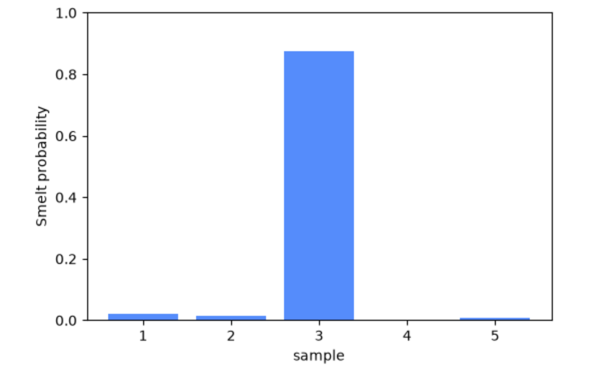

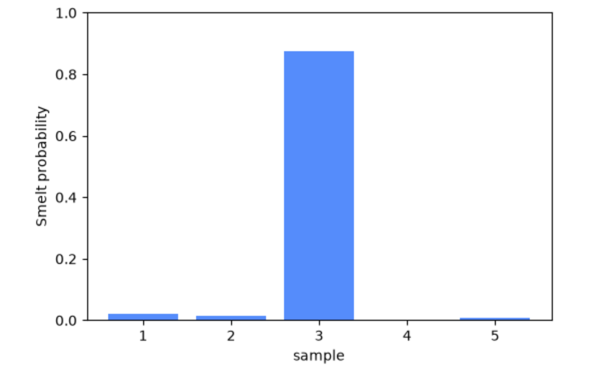

In [33]:
# 작성: Smelt 클래스의 인덱스를 찾고, 첫 5개 샘플의 Smelt 확률을 가져오세요.


# 작성: Smelt 예측 확률을 막대그래프로 그리세요.
# 조건: x축은 sample, y축은 Smelt probability, y축 범위는 0~1로 설정하세요.
# 도전: y=0.5 기준선을 추가해 분류 기준을 함께 표시하세요.